In [ ]:
# Import necessary libraries
%pip install pandas openpyxl matplotlib scikit-learn seaborn matplotlib-venn  nbformat

import os
import re
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from dateutil import parser
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

# Set up file paths
output_folder_path = r'/content/drive/My Drive/Translated_Texts'

# Ensure downloaded resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize spaCy English model for POS tagging
nlp = spacy.load("en_core_web_sm")

# Define custom stopwords
custom_stopwords = {
    'name', 'postcode', 'address', 'phone', 'company', 'ag', 'content', 'management', 'telephone', 'fax', 'email',
    'attachment', 'page', 'here', 'there', 'some', 'many', 'company_1', 'company_2', 'company_3', 'company_4',
    'company_5', 'company_6', 'i', 'you', 'he', 'we', 'us', 'my', 'your', 'his', 'our', 'their', 'whose',
    'although', 'despite', 'because', 'yet', 'therefore', 'whether', 'either', 'nor', 'if', 'as well as',
    'instead', 'nevertheless', 'hence', 'for this reason', 'in addition', 'as a result', 'example', 'also',
    'first', 'second', 'third', 'further', 'additionally', 'continually', 'maybe', 'no', 'yes', 'often', 'now',
    'soon', 'always', 'still', 'mostly', 'already', 'thus', 'could', 'would', 'might', 'must', 'should',
    'including', 'etc'
}
stop_words = set(stopwords.words('english')) | custom_stopwords
lemmatizer = WordNetLemmatizer()

# Date pattern for regex-based extraction
month_names = [
    "january", "february", "march", "april", "may", "june", "july", "august",
    "september", "october", "november", "december",
    "jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec",
]
date_pattern = (
    r"\b(?:\d{1,2}[-/\s]?)?" + r"(?:" + "|".join(month_names) + r")[-/\s]?" + r"(?:\d{2,4})?\b"
    + r"|\b\d{1,2}[-/\s]\d{1,2}[-/\s]\d{2,4}\b"
)

# Function to extract dates using regex and parse them
def extract_dates(text):
    dates = []
    for match in re.finditer(date_pattern, text, flags=re.IGNORECASE):
        try:
            parsed_date = parser.parse(match.group(), fuzzy=True, dayfirst=True)
            dates.append(parsed_date.isoformat())
        except (ValueError, parser.ParserError):
            continue
    return dates if dates else None

# Function to preprocess text for topic modeling
def preprocess_text_for_topic_modeling(text):
    text = re.sub(r'\b\d+\b', '', text.lower())  # Lowercase and remove numbers
    text = re.sub(r'\W', ' ', text)  # Remove non-word characters

    # Process text with spaCy
    doc = nlp(text)

    processed_words = []
    for token in doc:
        # Keep only nouns, verbs, and adjectives, and filter out stopwords
        if token.pos_ in {"NOUN", "VERB", "ADJ"} and token.lemma_ not in stop_words:
            processed_words.append(token.lemma_)

    return ' '.join(processed_words)

# Read, preprocess, and extract dates for each document in the folder
text_data = {}
for file_name in os.listdir(output_folder_path):
    if file_name.endswith(".txt"):
        file_path = os.path.join(output_folder_path, file_name)

        # Read the text
        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()

        # Extract dates
        extracted_dates = extract_dates(text)

        # Preprocess text
        preprocessed_text = preprocess_text_for_topic_modeling(text)

        # Store preprocessed text and extracted dates
        text_data[file_name] = {
            "dates": extracted_dates,
            "processed_text": preprocessed_text
        }

# Display extracted dates and processed text for a few documents
for file, content in list(text_data.items())[:3]:  # Display first 3 for brevity
    print(f"\nFile: {file}")
    print(f"Extracted Dates: {content['dates']}")
    print(f"Preprocessed Text:\n{content['processed_text'][:500]}")  # Show first 500 characters of preprocessed text

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



File: translated_20140930_[COMPANY_2]_10011435-001_350565_001001_page_1.txt
Extracted Dates: ['2024-09-30T00:00:00']
Preprocessed Text:
report customer information foundation flexible retirement construction industry mandate customer investment profile reference currency chf type service custody investment strategy balance contact mail mail ch copy com

File: translated_20140930_[COMPANY_2]_10011435-001_350565_001001_page_11.txt
Extracted Dates: ['2024-09-30T00:00:00', '2024-10-13T00:00:00', '2024-12-31T00:00:00', '2024-09-30T00:00:00']
Preprocessed Text:
segment performance reporting create performance portfolio benchmark difference liquidity chf bond foreign bond total nd l itä ei ch sla n io n tie tie bl bl portfolio benchmark performance calculation net copy information performance detailed position

File: translated_20140930_[COMPANY_2]_10011435-001_350565_001001_page_10.txt
Extracted Dates: ['2024-09-30T00:00:00', '2024-10-13T00:00:00', '2024-12-31T00:00:00', '2024-09-30T00:00:0

In [ ]:
from pandas.errors import OutOfBoundsDatetime

# Aggregate all valid dates into a single list
all_dates = []
for file_content in text_data.values():
    if file_content["dates"]:  # Ensure there are dates for the file
        for date in file_content["dates"]:
            try:
                # Convert each date to pandas datetime
                all_dates.append(pd.to_datetime(date))
            except (OutOfBoundsDatetime, ValueError):
                continue  # Skip any invalid or out-of-bounds dates




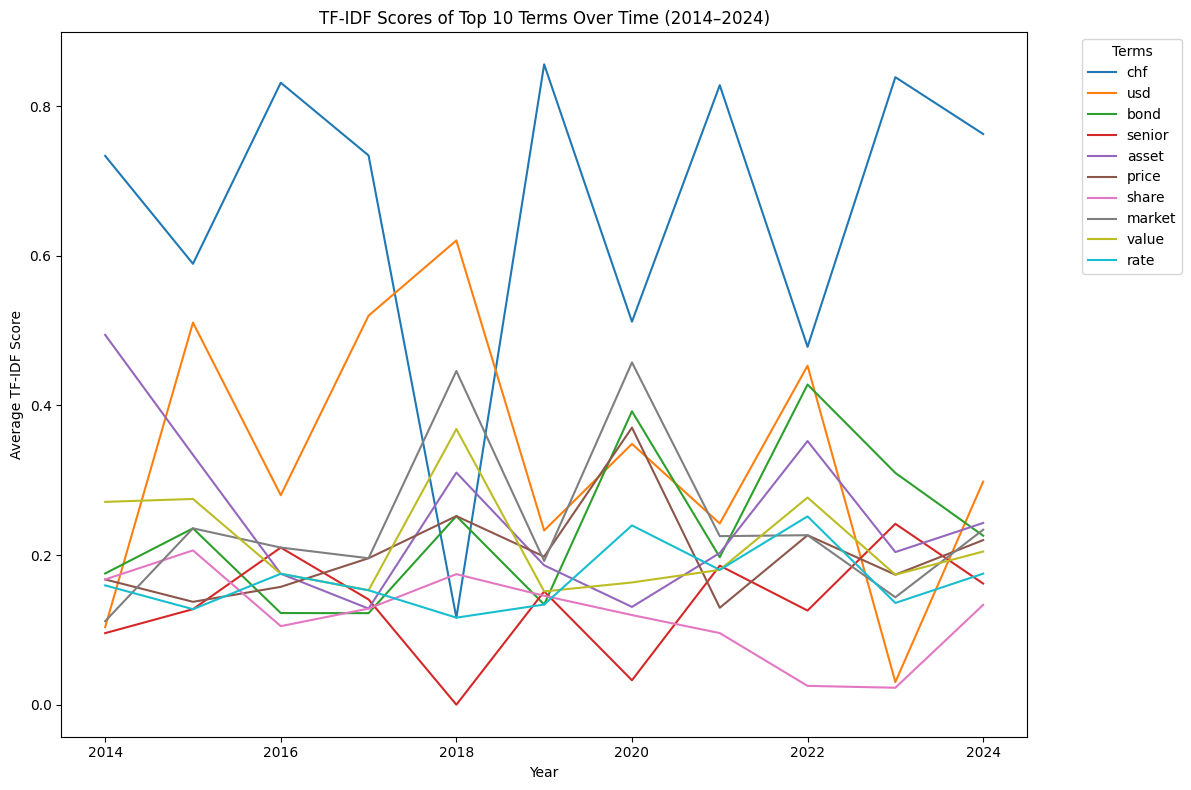

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the time frame and bin the extracted dates
dates_df = pd.DataFrame(valid_dates, columns=["Extracted Dates"])
dates_df["Year"] = dates_df["Extracted Dates"].dt.year
filtered_years = dates_df[(dates_df["Year"] >= 2014) & (dates_df["Year"] <= 2024)]

# Group by year
year_groups = filtered_years["Year"].value_counts().sort_index()

# Create a matrix with term frequency per year
tfidf_per_year = {year: [] for year in range(2014, 2025)}

# Assign texts to years (using filtered years)
for i, text in enumerate(processed_texts):
    # If no date, skip or use a placeholder year
    year = valid_dates[i].year if i < len(valid_dates) else None
    if year and 2014 <= year <= 2024:
        tfidf_per_year[year].append(text)

# Consolidate texts by year
aggregated_texts_per_year = {year: " ".join(tfidf_per_year[year]) for year in tfidf_per_year}

# Vectorize per year for the top 10 terms
top_terms_matrix = {term: [] for term in overall_top_terms}

for year, texts in aggregated_texts_per_year.items():
    if texts:
        tfidf_vectorizer_year = TfidfVectorizer(vocabulary=overall_top_terms)
        year_vectors = tfidf_vectorizer_year.fit_transform([texts]).toarray()
        year_scores = year_vectors.mean(axis=0)

        # Fill matrix with average TF-IDF score for each term
        for idx, term in enumerate(overall_top_terms):
            top_terms_matrix[term].append((year, year_scores[idx]))

# Prepare data for plotting
plot_data = []
for term, year_data in top_terms_matrix.items():
    for year, score in year_data:
        plot_data.append({"Year": year, "Term": term, "Score": score})

plot_df = pd.DataFrame(plot_data)

# Create the line plot
plt.figure(figsize=(12, 8))
for term in overall_top_terms:
    term_data = plot_df[plot_df["Term"] == term]
    plt.plot(term_data["Year"], term_data["Score"], label=term)

plt.title("TF-IDF Scores of Top 10 Terms Over Time (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Average TF-IDF Score")
plt.legend(title="Terms", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


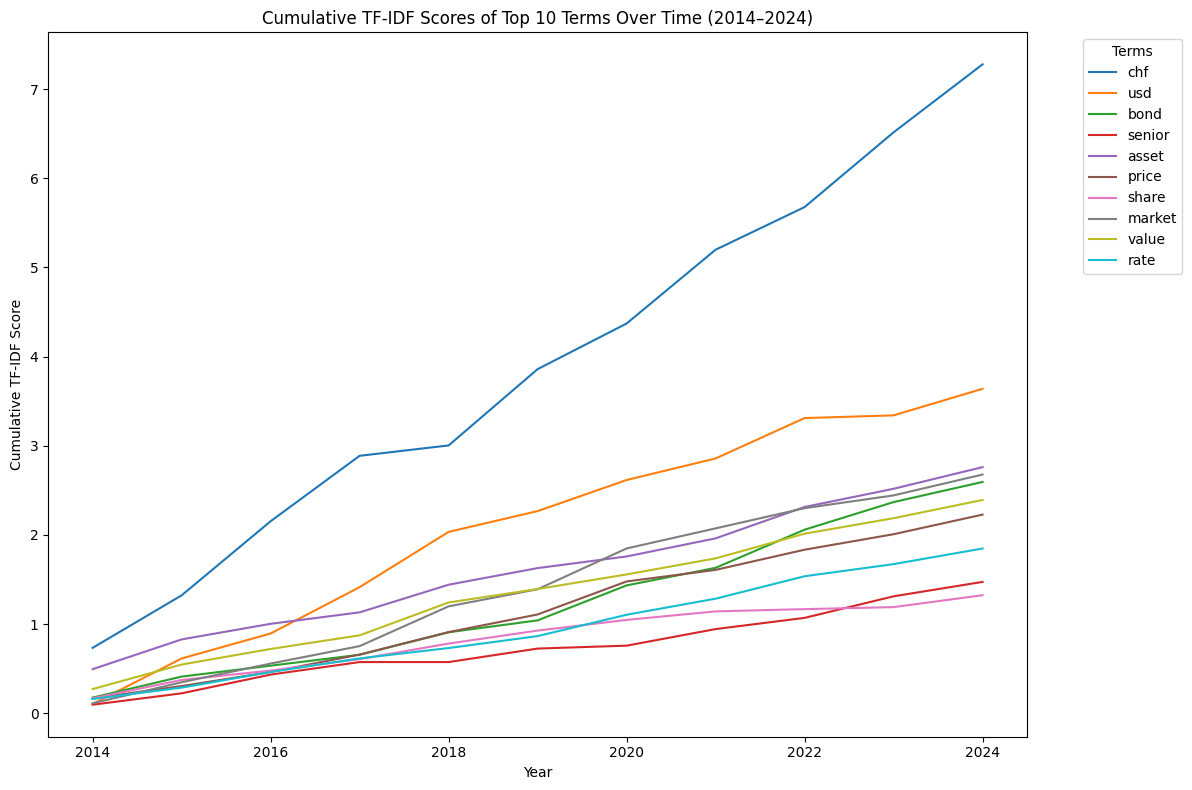

In [ ]:
# Add cumulative scores to plot_df
plot_df["Cumulative Score"] = plot_df.groupby("Term")["Score"].cumsum()

# Plot cumulative scores
plt.figure(figsize=(12, 8))
for term in overall_top_terms:
    term_data = plot_df[plot_df["Term"] == term]
    plt.plot(term_data["Year"], term_data["Cumulative Score"], label=term)

plt.title("Cumulative TF-IDF Scores of Top 10 Terms Over Time (2014–2024)")
plt.xlabel("Year")
plt.ylabel("Cumulative TF-IDF Score")
plt.legend(title="Terms", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
